# 02 · Sur un vrai magasin : combien de prévisions négatives, et à quel prix ?

**Bloc 6 · W37 — BayesReconPy, notebook 2 sur 2.**

> **La question du plan.** *Sur une hiérarchie de ventes intermittentes, combien de prévisions négatives MinT
> produit-il, et combien BayesReconPy en produit-il ?*

Le terrain est l'exemple de réconciliation discrète du dépôt BayesReconPy : le magasin **CA_1** de la
compétition M5 (Walmart), 3 049 articles et 11 agrégats, prévision à **un jour**. Les prévisions de base (modèle
ADAM) sont fournies avec le paquet.

| § | Contenu |
|---|---|
| 1 | Les données : à quel point les ventes sont-elles intermittentes ? |
| 2 | Quatre réconciliations, avec la même information |
| 3 | **La réponse** : les prévisions négatives, et le quality gate du bloc 3 |
| 4 | Pourquoi MinT passe sous zéro : le mécanisme |
| 5 | La précision : MASE, intervalles, RPS |
| 6 | 🔬 Validation contre la vignette R officielle |
| 7 | 🔬 Article par article : les écarts sont-ils systématiques ? |
| 8 | Conclusion |

> **Comment lire ce notebook.** Les encadrés suivent un code fixe :
> 💡 **Intuition**, l'idée sans les équations · 🧪 **Exemple**, une expérience chiffrée ·
> ⚠️ **Point d'attention**, le piège à éviter · 📌 **À retenir**, le mémo à garder ·
> 🔬 **Test d'hypothèse**, une hypothèse formulée, testée, puis acceptée ou rejetée.

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display, Markdown

from w37_reconciliation import viz
from w37_reconciliation.bayesrecon import example, methods, scores
from w37_reconciliation.bayesrecon.pmf import Normal

viz.setup()
pd.set_option("display.precision", 3)
FIG = Path("../figures"); FIG.mkdir(exist_ok=True)
def export(fig, name):
    fig.savefig(FIG / f"{name}.svg", bbox_inches="tight")

cfg, raw = example.load_config()
example.download(cfg, raw)                     # 76 Mo la première fois ; sha256 vérifié ensuite
ex = example.load_m5(raw)
RC = cfg["reconciliation"]; ALPHA = 1 - RC["interval"]
print(f"{ex.A.shape[0]} agrégats : {', '.join(ex.upper_names)}")
print(f"{ex.A.shape[1]:,} articles")

  déjà présent : M5_CA1_basefc.pkl
11 agrégats : CA_1, HOBBIES, HOUSEHOLD, FOODS, HOBBIES_1, HOBBIES_2, HOUSEHOLD_1, HOUSEHOLD_2, FOODS_1, FOODS_2, FOODS_3
3,049 articles


## 1. Les données : à quel point les ventes sont-elles intermittentes ?

Chaque article a une prévision de base **discrète** : une probabilité pour 0, 1, 2… ventes. On résume chacune
par deux nombres : la probabilité de ne rien vendre, P(0), et l'**indice de dispersion** (variance / moyenne),
qui vaut 1 pour une loi de Poisson et grandit avec les pics de ventes rares.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


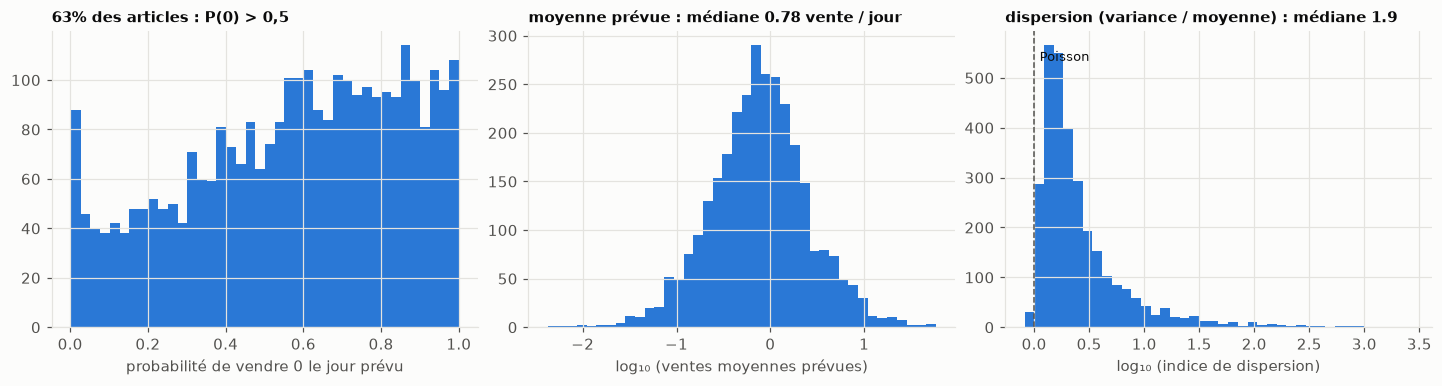

valeurs réalisées égales à 0 : 53% des articles
incohérence des prévisions de base : magasin 4,704 ventes, somme des articles 4,946


In [2]:
p0 = np.array([p.p[0] for p in ex.pmf_b])
mean_b, var_b = ex.mean_b, ex.var_b
disp = var_b / np.maximum(mean_b, 1e-12)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), layout="constrained")
axes[0].hist(p0, bins=40, color=viz.BLUE)
axes[0].set_title(f"{np.mean(p0 > 0.5):.0%} des articles : P(0) > 0,5", fontsize=9.5)
axes[0].set_xlabel("probabilité de vendre 0 le jour prévu")
axes[1].hist(np.log10(mean_b[mean_b > 0]), bins=40, color=viz.BLUE)
axes[1].set_title(f"moyenne prévue : médiane {np.median(mean_b):.2f} vente / jour", fontsize=9.5)
axes[1].set_xlabel("log₁₀ (ventes moyennes prévues)")
axes[2].hist(np.log10(disp[disp > 0]), bins=40, color=viz.BLUE)
axes[2].axvline(0, color=viz.TEXT_2, ls="--", lw=1); axes[2].text(0.05, axes[2].get_ylim()[1] * 0.9, "Poisson", fontsize=8.5)
axes[2].set_title(f"dispersion (variance / moyenne) : médiane {np.median(disp):.1f}", fontsize=9.5)
axes[2].set_xlabel("log₁₀ (indice de dispersion)")
export(fig, "m5_intermittence"); plt.show()
print(f"valeurs réalisées égales à 0 : {np.mean(ex.actual_b == 0):.0%} des articles")
print(f"incohérence des prévisions de base : magasin {ex.mu_u[0]:,.0f} ventes, somme des articles {mean_b.sum():,.0f}")

**Lecture.** C'est un terrain de longue traîne typique : la moitié des articles ne vendra rien le jour prévu, la
moyenne médiane est inférieure à une vente, et la dispersion est souvent bien supérieure à celle d'une loi de
Poisson. Et les prévisions de base sont **incohérentes** : le modèle du magasin prévoit environ 240 ventes de
moins que la somme des articles.

## 2. Quatre réconciliations, avec la même information

| méthode | ce qu'elle fait | W / information des agrégats |
|---|---|---|
| **MinT gaussien** | remplace chaque pmf par une gaussienne, projette (formule MinT) | Σ des 11 agrégats (Schäfer-Strimmer sur 1 941 jours de résidus) + variances des pmf |
| **bottom-up** | ignore les agrégats ; articles inchangés, agrégats = somme | — |
| **MixCond** | conditionne la loi jointe des articles sur les agrégats (BUIS) | même Σ |
| **TD-cond** | conditionne d'abord les agrégats, puis descend vers les articles | même Σ |

⚠️ **Point d'attention — MinT n'a pas de W pleine ici.** Les articles n'ont pas de résidus : on ne peut pas estimer
leurs covariances. La W de MinT est donc diagonale par blocs. C'est la même information que celle des méthodes
par conditionnement, qui supposent elles aussi les articles indépendants a priori.

⚠️ **Point d'attention — un effet de bord de BayesReconPy 0.5.0.** `reconc_td_cond` modifie **en place** les pmf
qu'on lui passe. Un appel suivant avec les mêmes objets peut échouer. Le module `methods` passe des copies
(test `test_conditioning_methods_do_not_mutate_their_inputs`).

In [3]:
recs = methods.run_all(ex, RC["num_samples"], RC["seed"])
by_name = {r.name: r for r in recs}
table = scores.summary(recs, ex, ALPHA)
display(table[["secondes", "incohérence max (ventes)"]].style.format({"secondes": "{:.1f}", "incohérence max (ventes)": "{:.2f}"}))
print(f"MixCond : taille d'échantillon effective (ESS) = {by_name['MixCond'].info['ESS']:.0f} sur {RC['num_samples']:,} tirages")

,secondes,incohérence max (ventes)
base,0.0,241.72
MinT gaussien,0.2,0.00
bottom-up,0.4,2.81
MixCond,0.8,0.00
TD-cond,5.8,0.00


MixCond : taille d'échantillon effective (ESS) = 2938 sur 10,000 tirages


Les trois méthodes réconciliées sont **cohérentes** (incohérence nulle). Le bottom-up probabiliste affiche un petit
écart : c'est l'erreur Monte-Carlo entre la moyenne exacte des pmf et la moyenne de leurs tirages ; ses
échantillons, eux, somment exactement. MixCond ne garde qu'environ 30 % de tirages « utiles » (ESS) : c'est la
perte d'efficacité de l'échantillonnage d'importance annoncée au notebook 01.

## 3. La réponse : combien de prévisions négatives ?

In [4]:
neg = table[[c for c in table.columns if c.startswith("articles ·") and ("<" in c or "masse" in c)]]
neg.columns = [c.replace("articles · ", "") for c in neg.columns]
display(neg.style.format({"moyennes < 0": "{:.0f}", "part moyennes < 0": "{:.2%}", "bornes basses < 0": "{:.0f}",
                          "part bornes basses < 0": "{:.1%}", "masse sous zéro (moyenne)": "{:.1%}"})
        .set_caption(f"Articles ({len(ex.pmf_b):,}) ; borne basse = quantile {ALPHA / 2:.0%}"))
mint = by_name["MinT gaussien"]
m = np.array([d.mean for d in mint.bottom])
print("les moyennes négatives de MinT :", np.sort(m[m < 0]).round(3))
limit = float(cfg["gate"]["max_negative_share"])
print(f"\nquality gate du bloc 3 (max_negative_share = {limit:g}) : "
      + ", ".join(f"{n} {'BLOQUÉ' if s > limit else 'OK'}" for n, s in table["articles · part moyennes < 0"].items()))

,moyennes < 0,part moyennes < 0,bornes basses < 0,part bornes basses < 0,masse sous zéro (moyenne)
base,0,0.00%,0,0.0%,0.0%
MinT gaussien,11,0.36%,2992,98.1%,14.6%
bottom-up,0,0.00%,0,0.0%,0.0%
MixCond,0,0.00%,0,0.0%,0.0%
TD-cond,0,0.00%,0,0.0%,0.0%


les moyennes négatives de MinT : [-1.821e+01 -9.050e-01 -7.190e-01 -3.880e-01 -2.020e-01 -1.170e-01
 -1.130e-01 -2.000e-02 -1.500e-02 -1.500e-02 -0.000e+00]

quality gate du bloc 3 (max_negative_share = 0.001) : base OK, MinT gaussien BLOQUÉ, bottom-up OK, MixCond OK, TD-cond OK


### La réponse

> **MinT gaussien : 11 prévisions moyennes négatives sur 3 049 articles (0,36 %)**, de −18,2 à −0,015 ventes,
> plus un artefact numérique (−0,000…) sur l'unique article de variance nulle. **Côté probabiliste, c'est massif : 98 % des intervalles à 90 % commencent sous zéro**, et MinT donne
> en moyenne 15 % de probabilité à des ventes impossibles.
>
> **BayesReconPy (MixCond, TD-cond) : 0**, par construction. Le bottom-up aussi, mais il n'est pas réconcilié
> au sens où il ignore les prévisions des agrégats.

**Traduction contractuelle.** Le contrat du bloc 3 fixe `max_negative_share: 0.001`. Avec 0,36 % de moyennes
négatives, **MinT gaussien serait bloqué** par la quality gate, et c'était sa raison d'être.

⚠️ **Point d'attention — la moyenne cache l'essentiel.** Le chiffre « 0,36 % de moyennes négatives » paraît
faible. Mais dès que la décision porte sur un **niveau de service** (un quantile), c'est la borne basse qui
compte, et elle est négative pour presque tous les articles.

## 4. Pourquoi MinT passe sous zéro : le mécanisme

Avec une W diagonale, MinT répartit la correction de chaque agrégat **au prorata des variances** des séries qui
le composent (bloc 2 et bloc 4). Un article dont la variance est grande devant sa moyenne reçoit une correction
qui peut dépasser sa moyenne.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


corrélation entre l'ajustement MinT et la variance de base : -0.98
indice de dispersion, médiane : articles passés sous zéro 183 ; autres 1.9


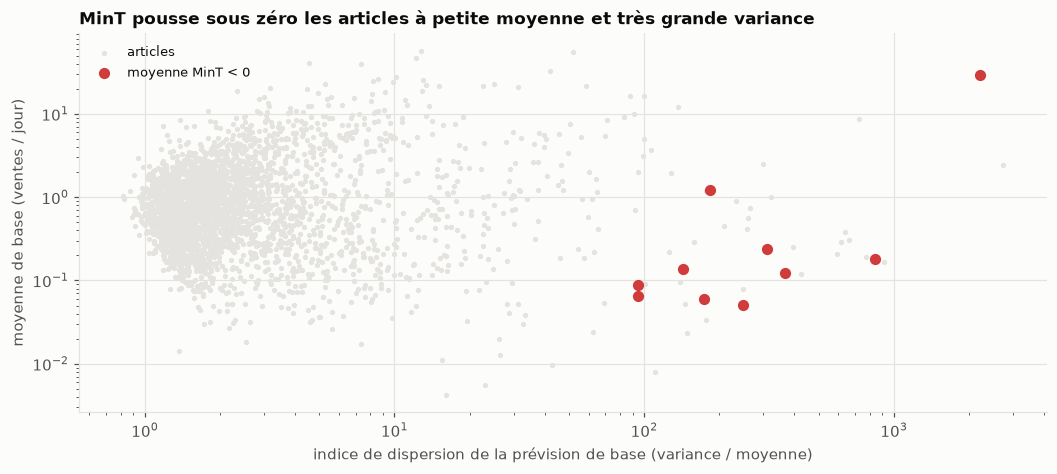

In [5]:
adj = m - mean_b
negm = m < 0
print(f"corrélation entre l'ajustement MinT et la variance de base : {np.corrcoef(adj, var_b)[0, 1]:+.2f}")
print(f"indice de dispersion, médiane : articles passés sous zéro {np.median(disp[negm]):.0f} ; autres {np.median(disp[~negm]):.1f}")
fig, ax = plt.subplots(figsize=(9.5, 4.2), layout="constrained")
ok = (mean_b > 0) & ~negm
ax.scatter(disp[ok], mean_b[ok], s=6, color=viz.GRID, label="articles")
sel = negm & (mean_b > 0)
ax.scatter(disp[sel], mean_b[sel], s=40, color=viz.CRITICAL, label="moyenne MinT < 0", zorder=3)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("indice de dispersion de la prévision de base (variance / moyenne)")
ax.set_ylabel("moyenne de base (ventes / jour)")
ax.legend(fontsize=8.5, loc="upper left")
ax.set_title("MinT pousse sous zéro les articles à petite moyenne et très grande variance")
export(fig, "m5_mecanisme_negatifs"); plt.show()

**Lecture.** Les articles passés sous zéro sont **à droite** (et pour la plupart en bas) : petite moyenne, dispersion énorme (une
prévision qui dit « presque toujours 0, parfois un gros pic »). La correction MinT, proportionnelle à la
variance, est plus grande que leur moyenne. Une gaussienne n'a aucun moyen de savoir qu'une vente ne peut
pas être négative.

💡 **Ce que fait le conditionnement à la place.** Il repondère la loi de chaque article sans quitter les entiers :
un article « 0 ou gros pic » voit son pic devenir moins probable, jamais sa moyenne passer sous zéro.

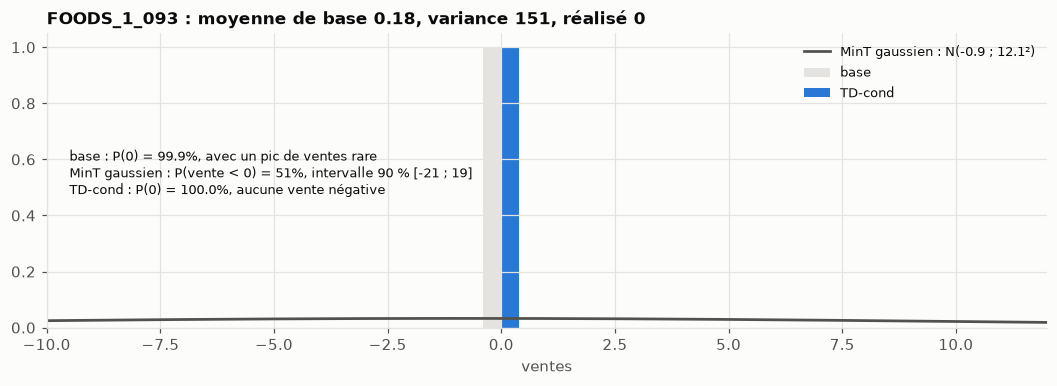

In [6]:
# un cas typique de la zone à risque : petite moyenne (< 2 ventes / jour), moyenne MinT négative
idx = int(np.argmin(np.where(negm & (mean_b > 0.1) & (mean_b < 2), m, np.inf)))
td = by_name["TD-cond"].bottom[idx]
fig, ax = plt.subplots(figsize=(9.5, 3.4), layout="constrained")
K = 12
ax.bar(np.arange(K) - 0.2, ex.pmf_b[idx].p[:K], width=0.4, color=viz.GRID, label="base")
ax.bar(np.arange(K) + 0.2, np.r_[td.p, np.zeros(K)][:K], width=0.4, color=viz.BLUE, label="TD-cond")
d = mint.bottom[idx]; x = np.linspace(-10, K, 400)
ax.plot(x, stats.norm.pdf(x, d.mu, d.sd), color=viz.TEXT_2, lw=1.8, label=f"MinT gaussien : N({d.mu:.1f} ; {d.sd:.1f}²)")
ax.set_xlim(-10, K); ax.set_xlabel("ventes"); ax.legend(fontsize=8.5)
ax.text(-9.5, 0.55, f"base : P(0) = {ex.pmf_b[idx].p[0]:.1%}, avec un pic de ventes rare\n"
        f"MinT gaussien : P(vente < 0) = {d.prob_negative():.0%}, intervalle 90 % "
        f"[{d.quantile(0.05):.0f} ; {d.quantile(0.95):.0f}]\nTD-cond : P(0) = {td.p[0]:.1%}, aucune vente négative",
        fontsize=8.5, va="center")
ax.set_title(f"{ex.bottom_names[idx]} : moyenne de base {mean_b[idx]:.2f}, variance {var_b[idx]:.0f}, réalisé {ex.actual_b[idx]:.0f}")
export(fig, "m5_un_article"); plt.show()

## 5. La précision : MASE, intervalles, RPS

Ne pas produire de négatifs ne suffit pas : il faut aussi être précis. Trois scores, plus bas = mieux :

- **MASE** : erreur de la médiane, divisée par l'erreur naïve de la série (échelles `Q` fournies avec l'exemple) ;
- **MIS** : largeur de l'intervalle à 90 % + pénalité si la valeur réalisée en sort ;
- **RPS** : écart entre la loi prévue et la valeur réalisée, sur les entiers (le score propre des comptages).

In [7]:
acc = table[[c for c in table.columns if c.endswith(("MASE", "MIS", "RPS"))]]
display(acc.style.format("{:.3f}").highlight_min(axis=0, color="#cde2fb")
        .set_caption("Un seul jour de prévision : 3 049 articles, 11 agrégats"))

,articles · MASE,articles · MIS,articles · RPS,agrégats · MASE,agrégats · MIS
base,1.080,5.750,0.676,0.779,452.061
MinT gaussien,1.352,7.992,0.819,0.956,1824.946
bottom-up,1.080,5.750,0.676,0.940,2329.818
MixCond,1.089,5.823,0.674,0.884,2311.909
TD-cond,1.092,5.746,0.669,0.791,443.909


**Lecture.**

- **MinT gaussien est le moins précis** sur les articles, pour les trois scores : forcer une gaussienne sur des
  comptages coûte en précision, pas seulement en vraisemblance.
- **TD-cond est le meilleur** en RPS et en MIS sur les articles, et le meilleur en MIS sur les agrégats ; en
  MASE, il reste très proche de la base.
- **MixCond et le bottom-up dégradent fortement les intervalles des agrégats** (MIS × 5) : la somme de 3 049
  articles supposés indépendants donne un total beaucoup trop étroit. C'est exactement la méthode B du bloc 4 :
  des échantillons indépendants sous-estiment la variance du total. TD-cond l'évite en partant des agrégats.

⚠️ **Point d'attention — un seul jour.** Ces scores portent sur **une** date de prévision. Le notebook R d'origine
(Zambon et al., 2024) moyenne sur 10 magasins × 14 jours. Les ordres de grandeur ci-dessous sont donc à lire
avec prudence, ce qu'aborde le § 7.

## 6. 🔬 Validation contre la vignette R officielle

La vignette [`mixed_reconciliation`](https://cran.r-project.org/web/packages/bayesRecon/vignettes/mixed_reconciliation.html)
du paquet R `bayesRecon` traite **le même magasin, les mêmes prévisions de base**. Elle publie des *skill scores*
(amélioration en % par rapport à la base, symétrique, moyennée sur les séries ; positif = mieux). Si notre
implémentation des scores et des méthodes est juste, on doit retrouver ses chiffres.

In [8]:
ours = scores.skill_table(recs, ex, ALPHA)[["MinT gaussien", "MixCond", "TD-cond"]]
published = pd.DataFrame(   # vignette R bayesRecon, consultée le 03/10/2026 ; « Gauss » = réconciliation gaussienne
    {"MinT gaussien": [-23.44, -66.19, -30.69, -89.48, -36.83, -55.62],
     "MixCond": [-12.61, -73.49, -24.99, -0.22, 0.22, 2.02],
     "TD-cond": [0.16, 1.64, -1.30, 0.11, 2.15, 3.90]},
    index=pd.MultiIndex.from_tuples([("agrégats", "MASE"), ("agrégats", "MIS"), ("agrégats", "RPS"),
                                     ("articles", "MASE"), ("articles", "MIS"), ("articles", "RPS")]))
cmp = pd.concat({"ce dépôt (Python)": ours.loc[published.index], "vignette (R)": published}, axis=1)
display(cmp.style.format("{:+.2f}"))
diff = (ours.loc[published.index] - published).abs()
print(f"écart absolu médian : {np.median(diff.to_numpy()):.2f} point ; écart maximal : {diff.to_numpy().max():.2f} point "
      f"({diff.stack().idxmax()})")

écart absolu médian : 0.15 point ; écart maximal : 7.00 point (('articles', 'RPS', 'MinT gaussien'))


**Conclusion de la validation.** La quasi-totalité des skill scores est retrouvée à quelques dixièmes de point,
y compris les très gros écarts de la méthode gaussienne (−23 %, −66 %, −89 %). Deux sources d'écart, connues :

- **MixCond et TD-cond** reposent sur des tirages aléatoires, et R et Python n'utilisent pas le même générateur
  (le README de BayesReconPy le signale) : les écarts de l'ordre du point sont du bruit Monte-Carlo ;
- **le RPS gaussien des articles** (−48,6 % ici, −55,6 % dans la vignette) dépend de la façon de discrétiser
  une loi normale sur les entiers. Nous utilisons P(Y ≤ k) = Φ((k + 0,5 − μ)/σ) ; la vignette utilise
  vraisemblablement une autre convention. Le signe et l'ordre de grandeur sont les mêmes.

📌 **Ce que la validation apporte.** Les chiffres de ce notebook ne reposent pas seulement sur notre code : ils
reproduisent une référence publiée et indépendante.

## 7. 🔬 Article par article : les écarts sont-ils systématiques ?

Avec un seul jour, on ne peut pas répéter l'expérience dans le temps. On peut en revanche comparer les méthodes
**article par article** : pour chacun, quelle méthode a le meilleur RPS ?

- **H0** : la différence de RPS entre deux méthodes est centrée sur zéro (test de Wilcoxon signé, apparié par
  article).

⚠️ **Point d'attention — les articles ne sont pas indépendants.** Ils partagent le même jour, donc les mêmes chocs
(météo, événement, jour de paie). Le test les traite comme indépendants : ses p-valeurs sont **trop
optimistes**. On les lit comme une description de la régularité des écarts, pas comme une preuve.

In [9]:
ps = {k: scores.per_series(by_name[k].bottom, ex.actual_b, ex.Q_b, ALPHA) for k in ["base", "MinT gaussien", "MixCond", "TD-cond"]}
rows = {}
for a, b in [("TD-cond", "base"), ("TD-cond", "MinT gaussien"), ("MixCond", "base"), ("MinT gaussien", "base")]:
    d = ps[a]["RPS"] - ps[b]["RPS"]
    rows[f"{a} vs {b}"] = {"articles où meilleur": (d < 0).mean(), "articles où pire": (d > 0).mean(),
                           "différence médiane de RPS": d.median(), "p Wilcoxon (indicatif)": stats.wilcoxon(d[d != 0]).pvalue}
display(pd.DataFrame(rows).T.style.format({"articles où meilleur": "{:.0%}", "articles où pire": "{:.0%}",
                                            "différence médiane de RPS": "{:+.4f}", "p Wilcoxon (indicatif)": "{:.1e}"}))

,articles où meilleur,articles où pire,différence médiane de RPS,p Wilcoxon (indicatif)
TD-cond vs base,59%,41%,-0.0008,3.7e-14
TD-cond vs MinT gaussien,66%,34%,-0.1090,5.5e-56
MixCond vs base,52%,48%,-0.0001,2.8e-01
MinT gaussien vs base,34%,66%,+0.1034,3.5e-60


**Lecture.**

- **TD-cond bat MinT gaussien sur environ deux articles sur trois**, avec une différence médiane nette : l'écart est
  régulier, pas porté par quelques articles.
- **TD-cond bat la base sur environ 6 articles sur 10**, mais la différence médiane est minuscule : le gain est
  réel et régulier, et petit.
- **MixCond ne se distingue pas de la base** sur les articles.

Pour conclure au sens statistique, il faudrait plusieurs dates de prévision (le protocole de Zambon et al. :
10 magasins × 14 jours). C'est la limite principale de cet exemple.

## 8. Conclusion

| | MinT gaussien | bottom-up | MixCond | TD-cond |
|---|---|---|---|---|
| moyennes négatives (articles) | **11 / 3 049** | 0 | 0 | 0 |
| intervalles à 90 % commençant sous zéro | **98 %** | 0 | 0 | 0 |
| quality gate du bloc 3 (`max_negative_share`) | **bloqué** | ok | ok | ok |
| précision des articles (RPS) | la pire | = base | ≈ base | **la meilleure** |
| intervalles des agrégats (MIS) | mauvais | très mauvais | très mauvais | **le meilleur** |
| temps de calcul | < 1 s | < 1 s | ≈ 1 s | ≈ 6 s |

📌 **À retenir — BayesReconPy sur des ventes intermittentes.**
1. **MinT gaussien produit des ventes négatives** : 0,36 % des moyennes, et **98 % des bornes basses** des
   intervalles. Il serait bloqué par la quality gate du bloc 3.
2. **Le conditionnement n'en produit aucune**, par construction : il repondère des lois discrètes sans quitter
   les entiers.
3. **TD-cond est la méthode à retenir** : seule à être à la fois cohérente, sans négatifs, et précise aux deux
   niveaux. MixCond (et le bottom-up) ratent les agrégats, pour la même raison que la méthode B du bloc 4.
4. **Nos chiffres reproduisent la vignette R officielle**, au bruit Monte-Carlo près.
5. **Limite** : un seul jour de prévision. La conclusion sur la précision est indicative ; celle sur les
   négatifs, elle, est structurelle.